# Taller ingeniería de datos

El problema que se desea resolver haciendo un modelo predictivo es el siguiente:

*En la industria de telecomunicaciones, la **retención de clientes** es uno de los mayores desafíos para las empresas, ya que la pérdida de clientes (churn) afecta directamente los ingresos y la sostenibilidad del negocio. En este contexto, la empresa que proporciona servicios de telecomunicaciones a través del dataset tiene como objetivo reducir la **tasa de cancelación de sus servicios**. En particular, la variable **Churn Label** identifica a aquellos clientes que han decidido abandonar el servicio. Para abordar este problema, es crucial predecir con antelación qué clientes podrían cancelar su suscripción, para implementar estrategias de retención específicas. Este análisis predictivo no solo ayudaría a identificar a los clientes en riesgo de churn, sino que también podría revelar factores determinantes como la **razón de cancelación**, **tipos de contrato**, **método de pago**, **tasa de uso** y otras variables que influyen en la decisión de los clientes. Por lo tanto, realizar un análisis predictivo basado en estas variables permitirá a la empresa tomar medidas proactivas para mejorar su **estrategia de fidelización** y, en última instancia, reducir el churn y aumentar la **rentabilidad** a largo plazo.*

El equipo de análisis cuenta con un dataset cuyo diccionario de datos se puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

## Carga e identificación de problemas de los datos

Abra el archivo de datos en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargue en `Pandas` el archivo dado, que contiene un dataset cuya información puede consultar en [IBM](https://community.ibm.com/community/user/businessanalytics/blogs/steven-macko/2019/07/11/telco-customer-churn-1113).

Indique cuántas variables y registros tiene el dataset, y asegúrese que el tipo de dato de cada variable sea el esperado.

Reporte las estadísticas descriptivas de las variables numéricas y categóricas.

Identifique si el dataframe tiene datos duplicados.

Identifique si hay variables con datos nulos.

Reporte los hallazgos en un celda de texto.

In [1]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / "data" / "raw"
data_file = "Telco_customer_churn.csv"
data_path = DATA_DIR / data_file

In [2]:
import pandas as pd

df = pd.read_csv(
    data_path,
    na_values=[' ']
    )
df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [4]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000


In [5]:
df.describe(include='object').T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"34.159534, -116.425984",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [6]:
df.isnull().sum().sort_values(ascending=False).head(5)

Churn Reason     5174
Total Charges      11
CustomerID          0
Count               0
Country             0
dtype: int64

In [7]:
df[['Total Charges', 'Churn Reason']].isnull().sum()*100/df.shape[0]

Total Charges     0.156183
Churn Reason     73.463013
dtype: float64

In [8]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


In [9]:
df = df.drop(columns=['Churn Reason'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [10]:
df = df.dropna(subset=['Total Charges'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7032 non-null   object 
 1   Count              7032 non-null   int64  
 2   Country            7032 non-null   object 
 3   State              7032 non-null   object 
 4   City               7032 non-null   object 
 5   Zip Code           7032 non-null   int64  
 6   Lat Long           7032 non-null   object 
 7   Latitude           7032 non-null   float64
 8   Longitude          7032 non-null   float64
 9   Gender             7032 non-null   object 
 10  Senior Citizen     7032 non-null   object 
 11  Partner            7032 non-null   object 
 12  Dependents         7032 non-null   object 
 13  Tenure Months      7032 non-null   int64  
 14  Phone Service      7032 non-null   object 
 15  Multiple Lines     7032 non-null   object 
 16  Internet Service   7032 non-n

#### 1. Preparación de datos
- El dataset tiene 33 variables y 7043 registros
- Customer ID es una clave primaria
- Count es una constante, 1
- Country y state son variables de un unico valor, City tiene muchos valores unicos
- La variable Lat Long contiene la misma información que las variables Latitude y Longitude
- Se elimina Churn Reason porque es una variable porque solo aparece cuando la variable churn Value es Positiva, lo que crearia un problema en nuestra predicción
- Se eliminan los registros con datos nulos en la variable Total Charges


Descarte las variables que considere irrelevantes para su modelo (p.e. claves priamrias, variables con valores únicos, variables redundantes, entre otros).

Gestione los datos duplicados y los datos nulos.

In [11]:
df = df.set_index('CustomerID')
df = df.drop(columns=['Count', 'Country', 'State', 'City', 'Lat Long'])
df.head()

,Zip Code,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,...,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV
CustomerID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,90003,33.964131,-118.272783,Male,No,No,No,2,Yes,No,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239
9237-HQITU,90005,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701
9305-CDSKC,90006,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,...,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372
7892-POOKP,90010,34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,...,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003
0280-XJGEX,90015,34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,...,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340


**Variables descartadas**

- Convertir CustomerId en un indice, o eliminar la variable
- Eliminar las variables Count, Country, State, City y Lat Long
- Quedaron 7032 registros y 27 variables

## Análisis de variables categóricas

Haga un análisis de las variables categóricas no descartadas, e identifique:

- Variables nominales.
- Variables ordinales.
- Variables con alta cardinalidad.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

In [12]:
df.describe(include='object').T

,count,unique,top,freq
Gender,7032,2,Male,3549
Senior Citizen,7032,2,No,5890
Partner,7032,2,No,3639
Dependents,7032,2,No,5412
Phone Service,7032,2,Yes,6352
Multiple Lines,7032,3,No,3385
Internet Service,7032,3,Fiber optic,3096
Online Security,7032,3,No,3497
Online Backup,7032,3,No,3087
Device Protection,7032,3,No,3094


In [13]:
cat_vars = df.select_dtypes(include='object').columns
for var in cat_vars:
    print(f'{var}:\n {df[var].unique()} unique values \n')

Gender:
 ['Male' 'Female'] unique values 

Senior Citizen:
 ['No' 'Yes'] unique values 

Partner:
 ['No' 'Yes'] unique values 

Dependents:
 ['No' 'Yes'] unique values 

Phone Service:
 ['Yes' 'No'] unique values 

Multiple Lines:
 ['No' 'Yes' 'No phone service'] unique values 

Internet Service:
 ['DSL' 'Fiber optic' 'No'] unique values 

Online Security:
 ['Yes' 'No' 'No internet service'] unique values 

Online Backup:
 ['Yes' 'No' 'No internet service'] unique values 

Device Protection:
 ['No' 'Yes' 'No internet service'] unique values 

Tech Support:
 ['No' 'Yes' 'No internet service'] unique values 

Streaming TV:
 ['No' 'Yes' 'No internet service'] unique values 

Streaming Movies:
 ['No' 'Yes' 'No internet service'] unique values 

Contract:
 ['Month-to-month' 'Two year' 'One year'] unique values 

Paperless Billing:
 ['Yes' 'No'] unique values 

Payment Method:
 ['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)'] unique values 

Churn La

In [14]:
#tablas de contingencia
for var in cat_vars:
    tabla = pd.crosstab(df[var], df['Churn Value'], normalize='index')
    print(f'{var}:')
    print(tabla)
    print('\n')

Gender:
Churn Value         0         1
Gender                         
Female       0.730405  0.269595
Male         0.737954  0.262046


Senior Citizen:
Churn Value            0         1
Senior Citizen                    
No              0.763497  0.236503
Yes             0.583187  0.416813


Partner:
Churn Value         0         1
Partner                        
No           0.670239  0.329761
Yes          0.802829  0.197171


Dependents:
Churn Value         0         1
Dependents                     
No           0.674242  0.325758
Yes          0.934568  0.065432


Phone Service:
Churn Value           0         1
Phone Service                    
No             0.750000  0.250000
Yes            0.732525  0.267475


Multiple Lines:
Churn Value              0         1
Multiple Lines                      
No                0.749188  0.250812
No phone service  0.750000  0.250000
Yes               0.713515  0.286485


Internet Service:
Churn Value              0         1
Internet Ser

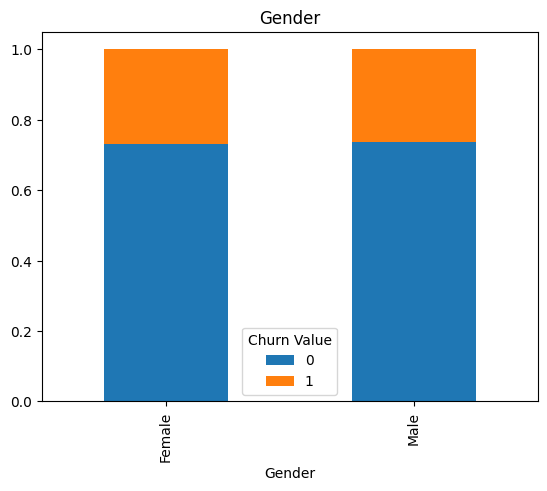

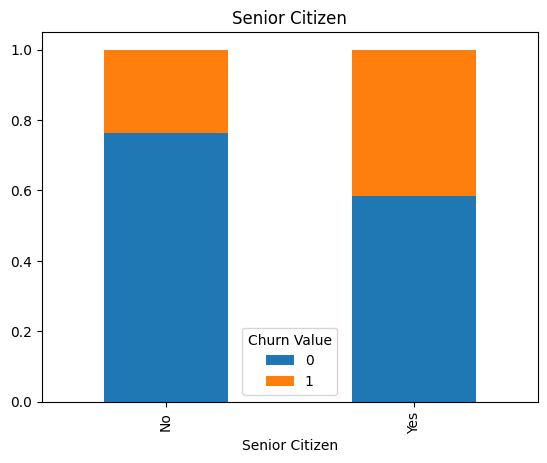

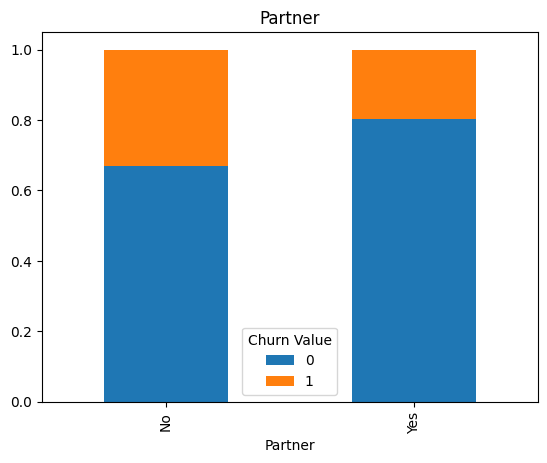

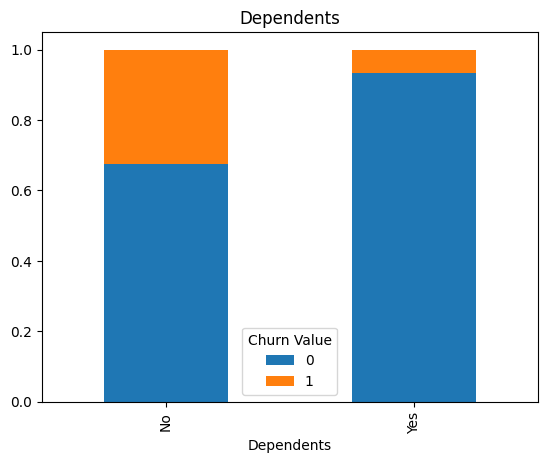

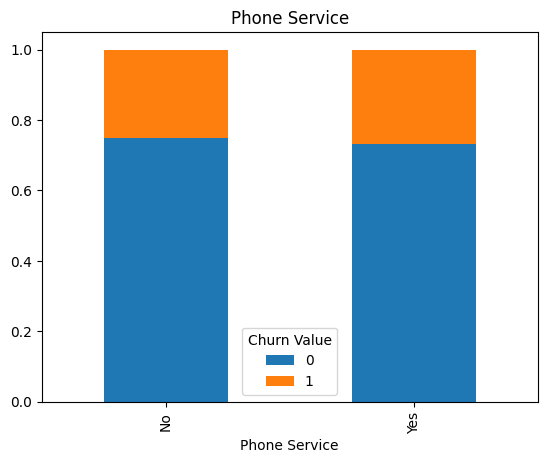

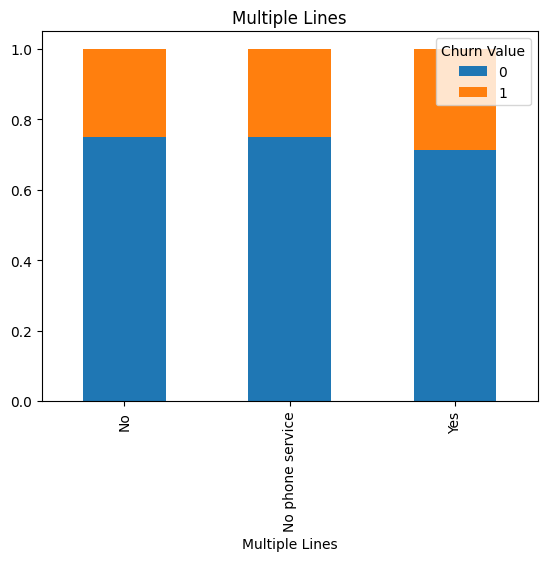

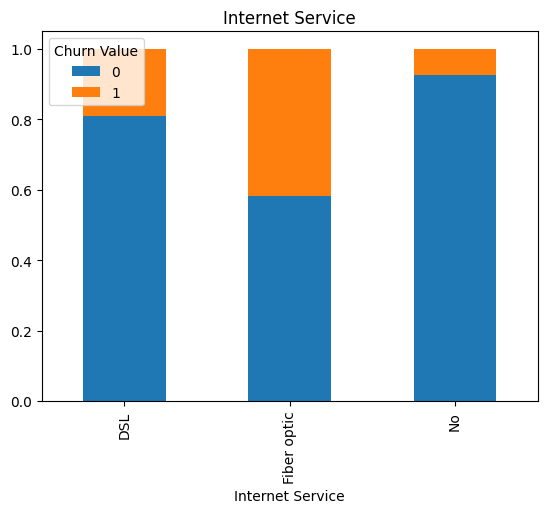

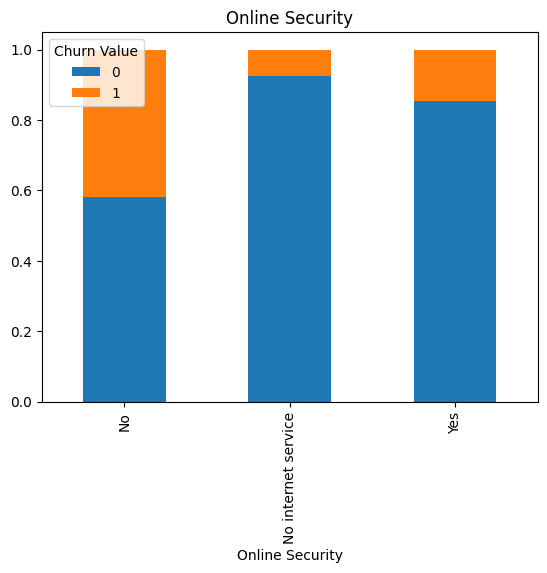

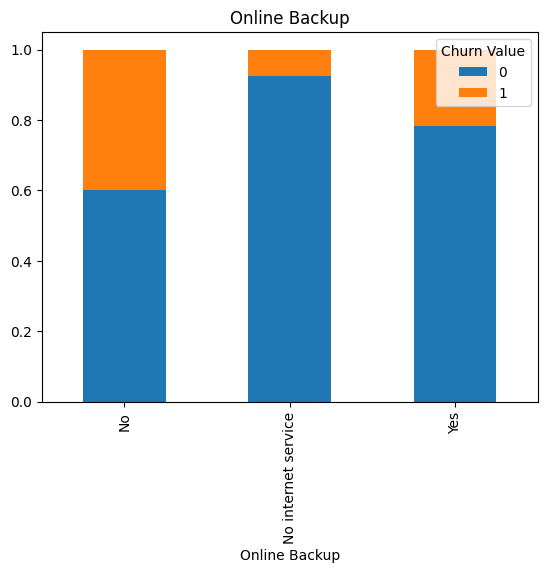

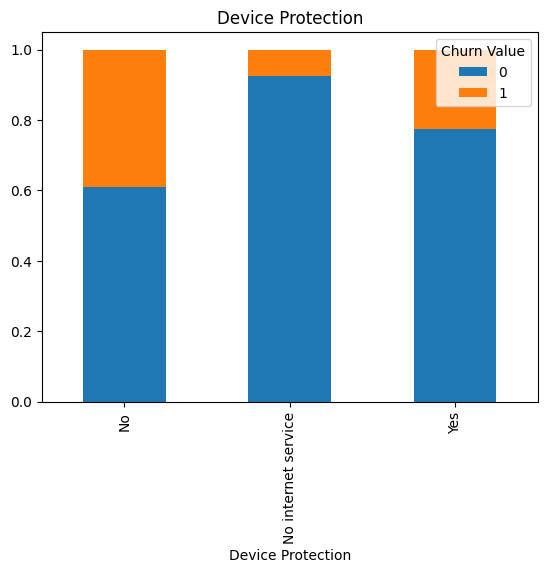

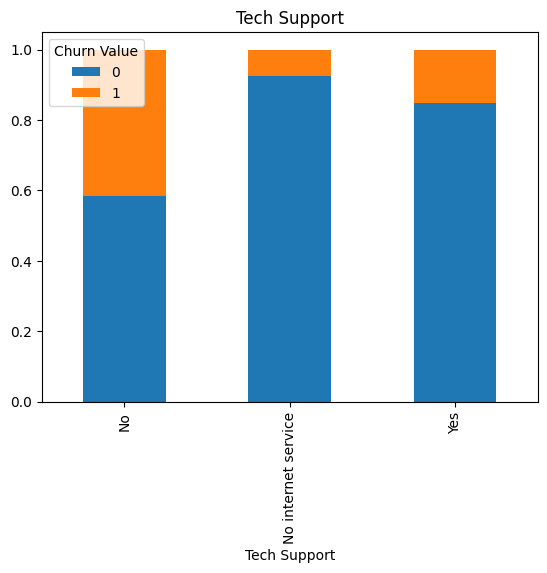

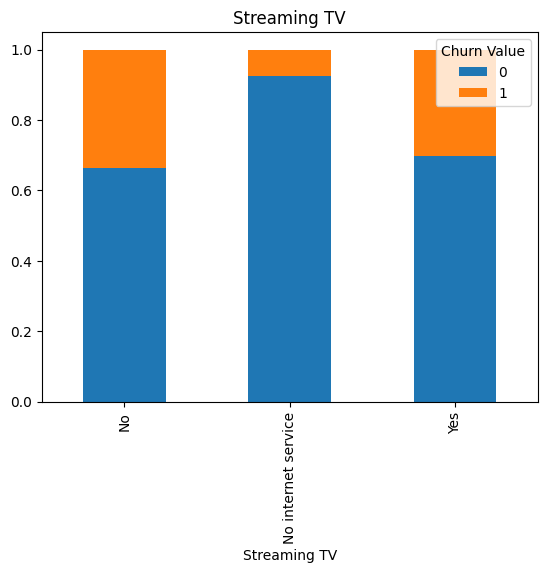

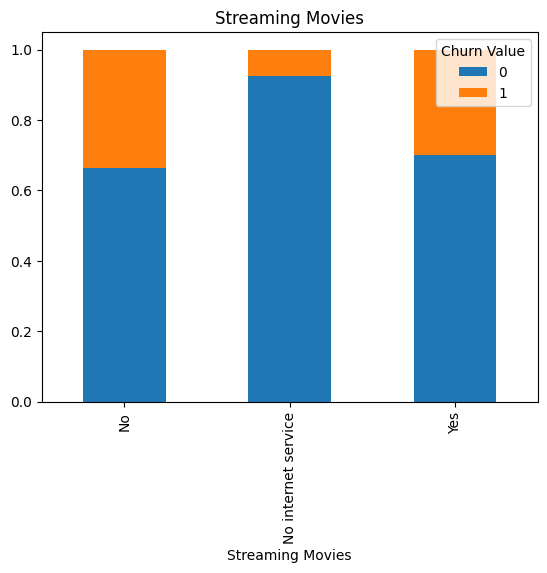

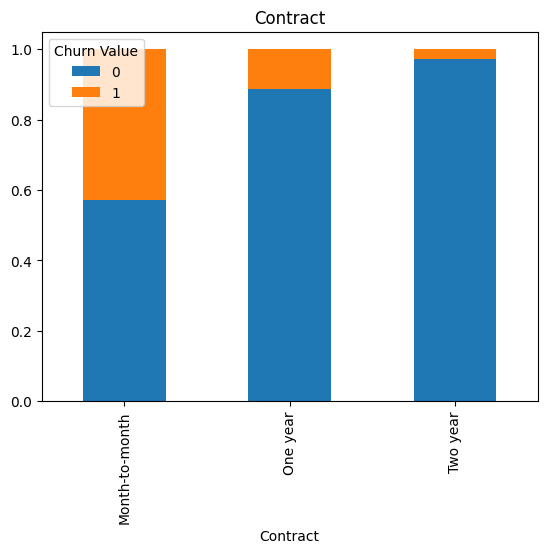

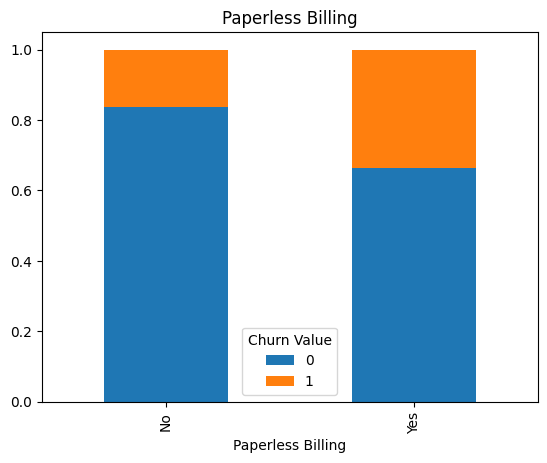

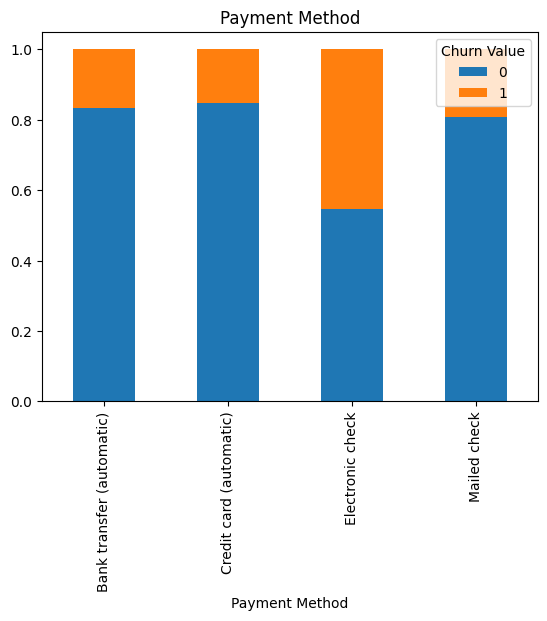

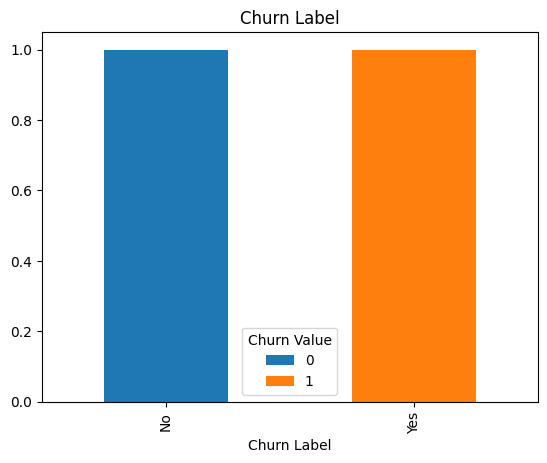

In [15]:
import matplotlib.pyplot as plt

for var in cat_vars:
    tabla = pd.crosstab(df[var], df['Churn Value'], normalize='index')
    tabla.plot(kind='bar', stacked=True)
    plt.title(var)
    plt.show()

#### 2. Análisis de varriables cualitativas
- Variables nominales:
  - `Senior Citizen` (Yes / No)
  - `Partner`, `Dependents`
  - `Phone Service`, `Multiple Lines`
  - `Internet Service` (DSL / Fiber optic / No)
  - `Online Security`, `Online Backup`, `Device Protection`, `Tech Support`
  - `Streaming TV`, `Streaming Movies`
  - `Paperless Billing`
  - `Payment Method` (4 categorías)

- Variables ordinales:
  - `Contract`: Month-to-month < One year < Two year (mayor permanencia implica menor probabilidad de churn)
  - No hay variables con alta cardinalidad
- Las variables que no deberian incluirse en la matriz de caracteristicas son: `Churn Label`: Es el target (versión texto de `Churn Value`) incluirla sería leakage total y `Gender` según la evealuación con `crosstab` no es una buena predictoria


In [16]:
df = df.drop(columns=['Gender', 'Churn Label'])
df.head()

,Zip Code,Latitude,Longitude,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,...,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV
CustomerID,,,,,,,,,,,,,,,,,,,,,
3668-QPYBK,90003,33.964131,-118.272783,No,No,No,2,Yes,No,DSL,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,86,3239
9237-HQITU,90005,34.059281,-118.307420,No,No,Yes,2,Yes,No,Fiber optic,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,67,2701
9305-CDSKC,90006,34.048013,-118.293953,No,No,Yes,8,Yes,Yes,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1,86,5372
7892-POOKP,90010,34.062125,-118.315709,No,Yes,Yes,28,Yes,Yes,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1,84,5003
0280-XJGEX,90015,34.039224,-118.266293,No,No,Yes,49,Yes,Yes,Fiber optic,...,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1,89,5340


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Zip Code           7032 non-null   int64  
 1   Latitude           7032 non-null   float64
 2   Longitude          7032 non-null   float64
 3   Senior Citizen     7032 non-null   object 
 4   Partner            7032 non-null   object 
 5   Dependents         7032 non-null   object 
 6   Tenure Months      7032 non-null   int64  
 7   Phone Service      7032 non-null   object 
 8   Multiple Lines     7032 non-null   object 
 9   Internet Service   7032 non-null   object 
 10  Online Security    7032 non-null   object 
 11  Online Backup      7032 non-null   object 
 12  Device Protection  7032 non-null   object 
 13  Tech Support       7032 non-null   object 
 14  Streaming TV       7032 non-null   object 
 15  Streaming Movies   7032 non-null   object 
 16  Contract      

Quedaron 7032 registros con 24 variables

## Análisis de variables cuantitativas

Haga un análisis de las variables cuantitativas no descartadas, e identifique:

- Variables que son aproximadamente normales.
- Variables con datos atípicos.
- Variables que no deberían incluirse en la matriz de características.

Reporte los resultados del análisis en una celda de texto.

array([[<Axes: title={'center': 'Zip Code'}>,
        <Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>],
       [<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'Total Charges'}>],
       [<Axes: title={'center': 'Churn Value'}>,
        <Axes: title={'center': 'Churn Score'}>,
        <Axes: title={'center': 'CLTV'}>]], dtype=object)

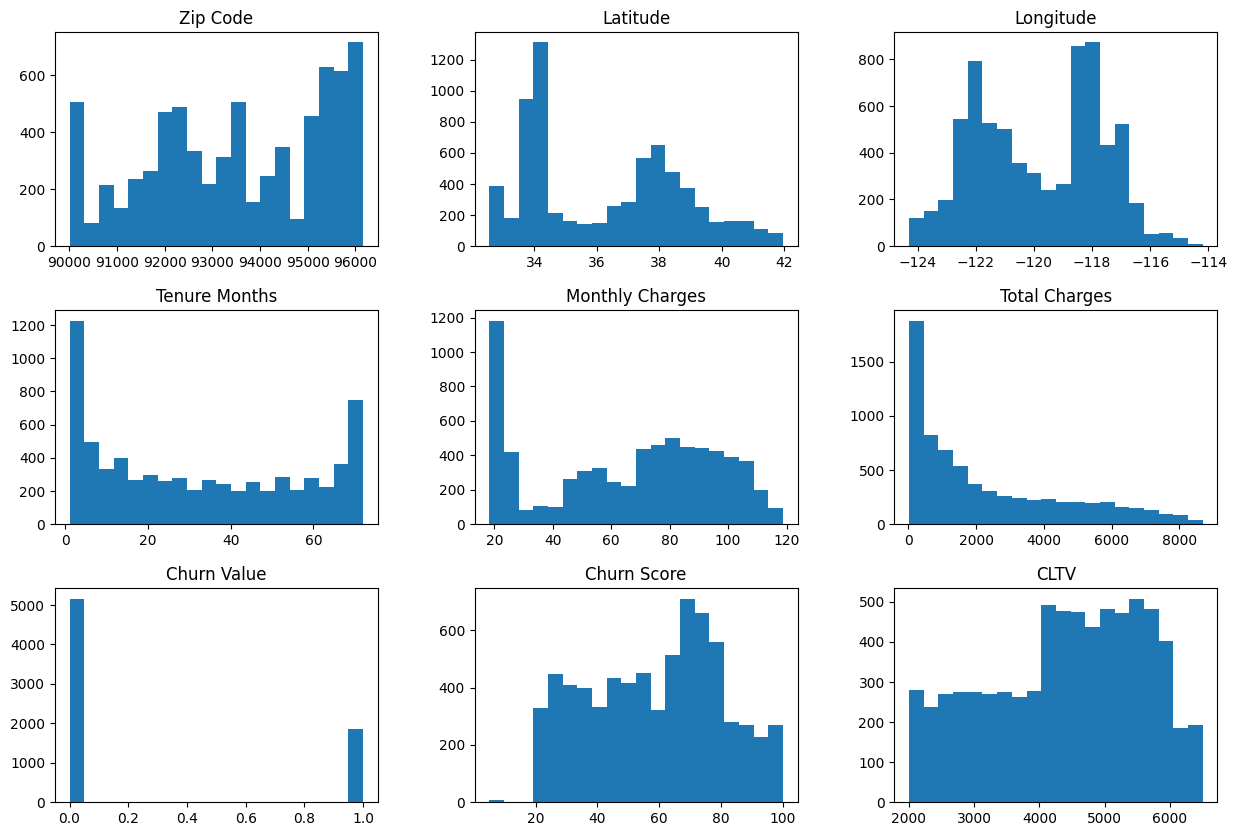

In [18]:
df.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(3,3))

Zip Code              Axes(0.125,0.653529;0.227941x0.226471)
Latitude           Axes(0.398529,0.653529;0.227941x0.226471)
Longitude          Axes(0.672059,0.653529;0.227941x0.226471)
Tenure Months         Axes(0.125,0.381765;0.227941x0.226471)
Monthly Charges    Axes(0.398529,0.381765;0.227941x0.226471)
Total Charges      Axes(0.672059,0.381765;0.227941x0.226471)
Churn Value               Axes(0.125,0.11;0.227941x0.226471)
Churn Score            Axes(0.398529,0.11;0.227941x0.226471)
CLTV                   Axes(0.672059,0.11;0.227941x0.226471)
dtype: object

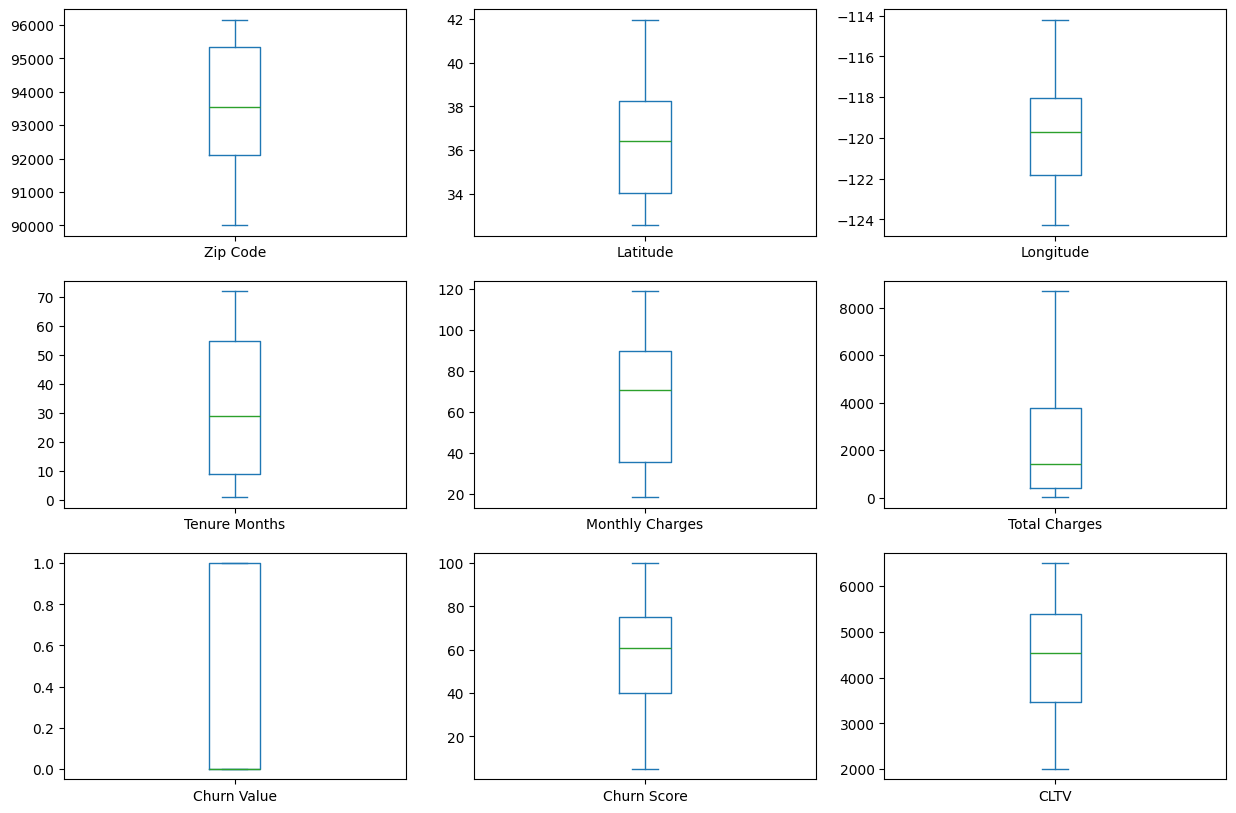

In [19]:
df.plot(kind='box', subplots=True, layout=(3,3), figsize=(15,10))

#### 3. Análisis de variables cuantitativas
- Variables aproximadamente normales:
  1. `Monthly Charges`: aunque bimodal, sus dos grupos son simétricos y no presenta outliers extremos.

- Variables con distribución asimétrica (sin outliers):
  1. `Tenure Months`: distribución sesgada con acumulación en 0 y un segundo pico en el mes 72 (fin de contrato), lo que genera valores atípicos en los extremos.
  2. `Total Charges`: distribución exponencial muy sesgada a la derecha, consecuencia de ser el producto acumulado de Tenure Months y Monthly Charges.
- Se deben descartar
    1. `Zip Code`: Son códigos postales, números que no tienen relación matemática real (91000 no es "más" que 90000). Es un identificador geográfico.
    2. `Latitude` y `Longitude`: Coordenadas geográficas. Además su distribución no refleja un fenómeno continuo útil para el modelo.
    3. `Churn Value`: es la variable a predecir.
    4. `Churn Score`: Score derivado del churn
    5. `CLTV`: Calculado con información de retención.


In [20]:
df = df.drop(columns=['Zip Code', 'Latitude', 'Longitude', 'Churn Score', 'CLTV'])
df.head()

,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
CustomerID,,,,,,,,,,,,,,,,,,,
3668-QPYBK,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
9237-HQITU,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
9305-CDSKC,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
7892-POOKP,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
0280-XJGEX,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


array([[<Axes: title={'center': 'Tenure Months'}>,
        <Axes: title={'center': 'Monthly Charges'}>,
        <Axes: title={'center': 'Total Charges'}>],
       [<Axes: title={'center': 'Churn Value'}>, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

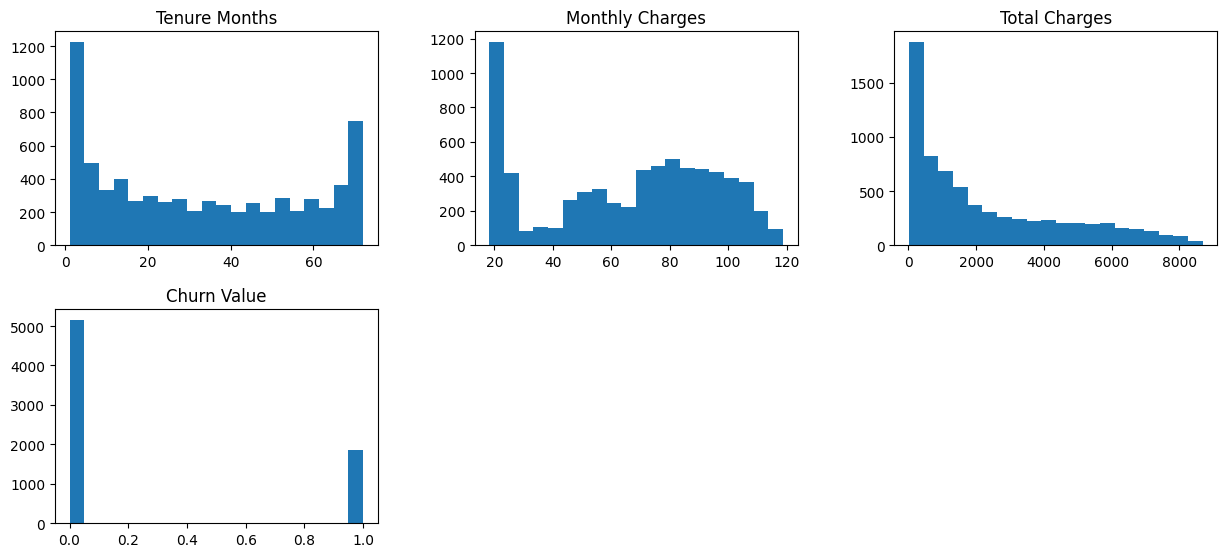

In [21]:
df.select_dtypes('number').hist(bins=20, figsize=(15,10), grid=False, layout=(3,3))

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 3668-QPYBK to 3186-AJIEK
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Senior Citizen     7032 non-null   object 
 1   Partner            7032 non-null   object 
 2   Dependents         7032 non-null   object 
 3   Tenure Months      7032 non-null   int64  
 4   Phone Service      7032 non-null   object 
 5   Multiple Lines     7032 non-null   object 
 6   Internet Service   7032 non-null   object 
 7   Online Security    7032 non-null   object 
 8   Online Backup      7032 non-null   object 
 9   Device Protection  7032 non-null   object 
 10  Tech Support       7032 non-null   object 
 11  Streaming TV       7032 non-null   object 
 12  Streaming Movies   7032 non-null   object 
 13  Contract           7032 non-null   object 
 14  Paperless Billing  7032 non-null   object 
 15  Payment Method     7032 non-null   object 
 16  Monthly Charge

Quedaron 7032 registros con 18 variables

## Entrenamiento del modelo

Entrene un modelo de árbol de decisión que prediga la variable **Churn Value**.

Procese las variables de acuerdo con los análisis de variables cuantitativas y categóricas hechos previamente. Este procesamiento debe empaquetarse usando `ColumnTransformer`, para que los datos de entrenamiento y prueba sean procesados por separado.

Reporte los `scores` de entrenamiento y prueba.

Reporte las características con las que **realmente** fue entrenado el modelo, es decir, las resultantes del preprocesamiento.

In [23]:
from sklearn.model_selection import train_test_split

X = df.drop(['Churn Value'], axis=1)
y = df['Churn Value']

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1, train_size=0.8)
print(f'Tamaño del conjunto de entrenamiento es: {X_train.shape}')
print(f'Tamaño del conjunto de prueba es: {X_test.shape}')

Tamaño del conjunto de entrenamiento es: (5625, 18)
Tamaño del conjunto de prueba es: (1407, 18)


- `Contract`(Categorica) ordinal encoding
- `Senior Citizen`,`Partner`, `Dependents`, `Phone Service`, `Multiple Lines`, `Internet Service`, `Online Security`, `Online Backup`, `Device Protection`, `Tech Support`, `Streaming TV`, `Streaming Movies`, `Paperless Billing`, `Payment Method`(categorías) one-hot encoding


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    PowerTransformer,
)
from sklearn.tree import DecisionTreeClassifier

# --- Transformadores ---
ss  = StandardScaler()
pt  = PowerTransformer()
ore = OrdinalEncoder(categories=[['Month-to-month', 'One year', 'Two year']])
ohe = OneHotEncoder(sparse_output=False, drop='if_binary', handle_unknown='ignore')

# --- Columnas por grupo ---
cols_standard = ['Tenure Months', 'Monthly Charges']
cols_power    = ['Total Charges']
cols_ordinal  = ['Contract']
cols_ohe      = ['Senior Citizen', 'Partner', 'Dependents',
                 'Phone Service', 'Multiple Lines', 'Internet Service',
                 'Online Security', 'Online Backup', 'Device Protection',
                 'Tech Support', 'Streaming TV', 'Streaming Movies',
                 'Paperless Billing', 'Payment Method']

# --- ColumnTransformer ---
preprocessor = ColumnTransformer(transformers=[
    ('standard', ss,  cols_standard),
    ('power',    pt,  cols_power),
    ('ordinal',  ore, cols_ordinal),
    ('ohe',      ohe, cols_ohe),
], remainder='drop')

In [25]:
print(df.columns.tolist())

['Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']


In [26]:
X_train_processed = preprocessor.fit_transform(X_train, y_train)
X_test_processed = preprocessor.transform(X_test)

In [27]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=1, max_depth=5)
tree.fit(X_train_processed, y_train)

print('Train score:', tree.score(X_train_processed, y_train))
print('Test score: ', tree.score(X_test_processed, y_test))

print('\nFeatures del modelo:')
print(preprocessor.get_feature_names_out())
print('\nNúmero de features:', preprocessor.get_feature_names_out().shape[0])

Train score: 0.7960888888888888
Test score:  0.7867803837953091

Features del modelo:
['standard__Tenure Months' 'standard__Monthly Charges'
 'power__Total Charges' 'ordinal__Contract' 'ohe__Senior Citizen_Yes'
 'ohe__Partner_Yes' 'ohe__Dependents_Yes' 'ohe__Phone Service_Yes'
 'ohe__Multiple Lines_No' 'ohe__Multiple Lines_No phone service'
 'ohe__Multiple Lines_Yes' 'ohe__Internet Service_DSL'
 'ohe__Internet Service_Fiber optic' 'ohe__Internet Service_No'
 'ohe__Online Security_No' 'ohe__Online Security_No internet service'
 'ohe__Online Security_Yes' 'ohe__Online Backup_No'
 'ohe__Online Backup_No internet service' 'ohe__Online Backup_Yes'
 'ohe__Device Protection_No' 'ohe__Device Protection_No internet service'
 'ohe__Device Protection_Yes' 'ohe__Tech Support_No'
 'ohe__Tech Support_No internet service' 'ohe__Tech Support_Yes'
 'ohe__Streaming TV_No' 'ohe__Streaming TV_No internet service'
 'ohe__Streaming TV_Yes' 'ohe__Streaming Movies_No'
 'ohe__Streaming Movies_No internet servi

## Resultados del modelo

Se entrenó un árbol de decisión (`DecisionTreeClassifier`) con `max_depth=5`
para predecir la variable `Churn Value`.

**Scores:**
- Train score: 0.7961
- Test score: 0.7867

La diferencia mínima entre ambos scores indica que el modelo generaliza bien
y no presenta sobreajuste.

**Features resultantes del preprocesamiento:** 37 características, generadas a partir de:
- Estandarización (`StandardScaler`): `Tenure Months`, `Monthly Charges`
- Transformación de potencia (`PowerTransformer`): `Total Charges`
- Codificación ordinal (`OrdinalEncoder`): `Contract`
- One-Hot Encoding (`OneHotEncoder`): variables categóricas binarias y nominales,
  expandidas en columnas dummy.